# Part 2 — Bias Audit

**Objective:** Measure whether the baseline classifier treats comments about different demographic groups differently.

**Cohort Definitions (using soft-probability identity columns):**
- **High-black cohort:** `black >= 0.5`
- **Reference cohort:** `black < 0.1 AND white >= 0.5`

**Metrics per cohort:**
- True Positive Rate (TPR), False Positive Rate (FPR), False Negative Rate (FNR), Precision
- Disparate Impact Ratio = FPR(high-black) / FPR(reference)

**AIF360 metrics:**
- Statistical Parity Difference
- Equal Opportunity Difference

In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score
)

warnings.filterwarnings('ignore')

# AIF360
try:
    from aif360.datasets import BinaryLabelDataset
    from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
    AIF_AVAILABLE = True
    print('AIF360 available ✓')
except ImportError:
    AIF_AVAILABLE = False
    print('WARNING: AIF360 not available — install with: pip install aif360')
    print('AIF360 metrics will be skipped but all other bias analysis will proceed.')

AIF360 available ✓


## 1. Load Eval Set and Predictions

In [5]:
# Load eval set with identity columns (saved by Part 1)
df_eval = pd.read_csv('./eval_set.csv')
probs   = np.load('./eval_probs.npy')

with open('./best_threshold.json') as f:
    BEST_THR = json.load(f)['best_threshold']

print(f'Eval set shape: {df_eval.shape}')
print(f'Using decision threshold: {BEST_THR}')

# Attach predictions
df_eval = df_eval.reset_index(drop=True)
df_eval['prob_toxic'] = probs
df_eval['pred_label'] = (probs >= BEST_THR).astype(int)
df_eval['label']      = df_eval['label'].astype(int)  # ensure int

print('\nFirst 3 rows:')
df_eval[['comment_text','label','prob_toxic','pred_label','black','white']].head(3)

Eval set shape: (20000, 8)
Using decision threshold: 0.5

First 3 rows:


,comment_text,label,prob_toxic,pred_label,black,white
0,No problem!\n\nAnother access point to not onl...,0,0.094678,0,0.0,0.0
1,"Wow. Just... wow.\n\nI like these threads, tho...",0,0.326647,0,0.0,0.0
2,The truth is Mayor Mufi Hannemann and his Mana...,0,0.003179,0,0.0,0.0


## 2. Cohort Construction

In [6]:
# Identity columns treated as soft probabilities (NOT binarized)
# High-black: black >= 0.5
mask_high_black = df_eval['black'] >= 0.5
# Reference: black < 0.1 AND white >= 0.5
mask_reference  = (df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)

df_high_black = df_eval[mask_high_black].copy()
df_reference  = df_eval[mask_reference].copy()

print(f'High-black cohort size : {len(df_high_black):,}')
print(f'Reference cohort size  : {len(df_reference):,}')
print(f'High-black toxic rate  : {df_high_black["label"].mean():.3f}')
print(f'Reference toxic rate   : {df_reference["label"].mean():.3f}')

High-black cohort size : 192
Reference cohort size  : 127
High-black toxic rate  : 0.365
Reference toxic rate   : 0.276


## 3. Per-Cohort Classification Metrics

In [7]:
def cohort_metrics(df, cohort_name):
    """Compute TPR, FPR, FNR, Precision for a cohort dataframe."""
    y_true = df['label'].values
    y_pred = df['pred_label'].values

    if len(df) == 0:
        return {'cohort': cohort_name, 'n': 0, 'TPR': None, 'FPR': None, 'FNR': None, 'Precision': None}

    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr  = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    return {
        'cohort': cohort_name, 'n': len(df),
        'TPR': tpr, 'FPR': fpr, 'FNR': fnr, 'Precision': prec,
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    }

metrics_hb  = cohort_metrics(df_high_black, 'High-Black')
metrics_ref = cohort_metrics(df_reference,  'Reference')

metrics_df = pd.DataFrame([metrics_hb, metrics_ref])
print(metrics_df[['cohort','n','TPR','FPR','FNR','Precision']].to_string(index=False))

# Disparate Impact Ratio
if metrics_ref['FPR'] and metrics_ref['FPR'] > 0:
    DIR = metrics_hb['FPR'] / metrics_ref['FPR']
else:
    DIR = float('inf')

print(f'\nDisparate Impact Ratio (FPR_high-black / FPR_reference) = {DIR:.4f}')
print('Interpretation: Values > 1 indicate higher false-positive rate for the high-black cohort')
print('                (i.e., non-toxic comments about Black topics are flagged more)')

    cohort   n      TPR      FPR      FNR  Precision
High-Black 192 0.128571 0.057377 0.871429   0.562500
 Reference 127 0.085714 0.043478 0.914286   0.428571

Disparate Impact Ratio (FPR_high-black / FPR_reference) = 1.3197
Interpretation: Values > 1 indicate higher false-positive rate for the high-black cohort
                (i.e., non-toxic comments about Black topics are flagged more)


## 4. AIF360 Fairness Metrics

In [8]:
if AIF_AVAILABLE:
    # Build a combined dataframe with group indicator
    df_combined = pd.concat([
        df_high_black.assign(group=0),   # unprivileged
        df_reference.assign(group=1),    # privileged
    ], ignore_index=True)

    # AIF360 requires: label col, protected attribute col, all numeric
    # True labels dataset
    ground_truth_ds = BinaryLabelDataset(
        df=df_combined[['label', 'group']].rename(columns={'label': 'toxic'}),
        label_names=['toxic'],
        protected_attribute_names=['group'],
        favorable_label=0,    # non-toxic is favorable
        unfavorable_label=1,
    )

    # Predicted labels dataset
    pred_ds = ground_truth_ds.copy()
    pred_ds.labels = df_combined[['pred_label']].values

    privileged_groups   = [{'group': 1}]
    unprivileged_groups = [{'group': 0}]

    clf_metric = ClassificationMetric(
        ground_truth_ds, pred_ds,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )

    spd = clf_metric.statistical_parity_difference()
    eod = clf_metric.equal_opportunity_difference()

    print('=' * 50)
    print('   AIF360 Fairness Metrics')
    print('=' * 50)
    print(f'Statistical Parity Difference : {spd:.4f}')
    print(f'  (ideal = 0; negative = higher predicted positive rate for reference)')
    print(f'Equal Opportunity Difference  : {eod:.4f}')
    print(f'  (ideal = 0; positive = higher TPR for high-black / lower for reference)')
else:
    print('AIF360 not available — skipping these metrics.')
    print('Manually computed proxy:')
    spd_proxy = (
        (df_combined := pd.concat([df_high_black.assign(group=0), df_reference.assign(group=1)]))
        .groupby('group')['pred_label'].mean().diff().iloc[-1]
    ) if 'df_combined' not in dir() else None

    # simple proxy
    df_c = pd.concat([df_high_black.assign(group=0), df_reference.assign(group=1)])
    pos_unpriv = df_c[df_c.group==0]['pred_label'].mean()
    pos_priv   = df_c[df_c.group==1]['pred_label'].mean()
    spd_proxy  = pos_unpriv - pos_priv
    print(f'Statistical Parity Difference (proxy) = {spd_proxy:.4f}')

   AIF360 Fairness Metrics
Statistical Parity Difference : -0.0282
  (ideal = 0; negative = higher predicted positive rate for reference)
Equal Opportunity Difference  : -0.0139
  (ideal = 0; positive = higher TPR for high-black / lower for reference)


## 5. Grouped Bar Chart — TPR, FPR, FNR

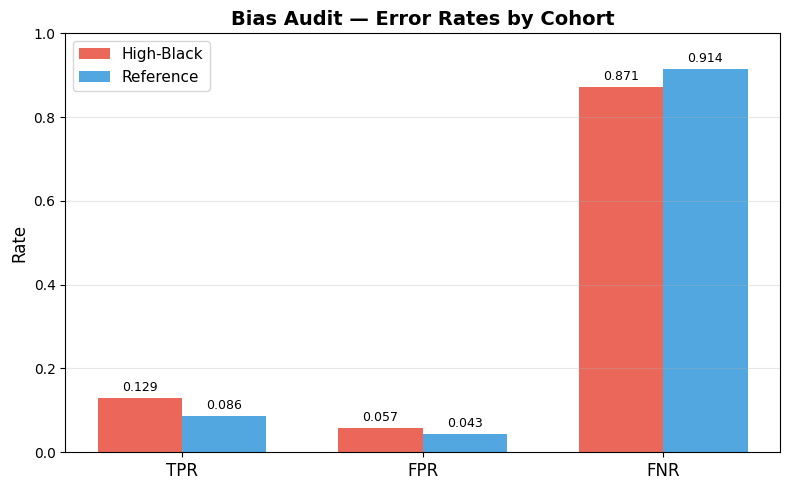

Saved bias_grouped_bar.png


In [9]:
categories = ['TPR', 'FPR', 'FNR']
hb_vals  = [metrics_hb[m]  for m in categories]
ref_vals = [metrics_ref[m] for m in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, hb_vals,  width, label='High-Black', color='#E74C3C', alpha=0.85)
bars2 = ax.bar(x + width/2, ref_vals, width, label='Reference',  color='#3498DB', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Rate', fontsize=12)
ax.set_title('Bias Audit — Error Rates by Cohort', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./bias_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bias_grouped_bar.png')

## 6. Confusion Matrices per Cohort

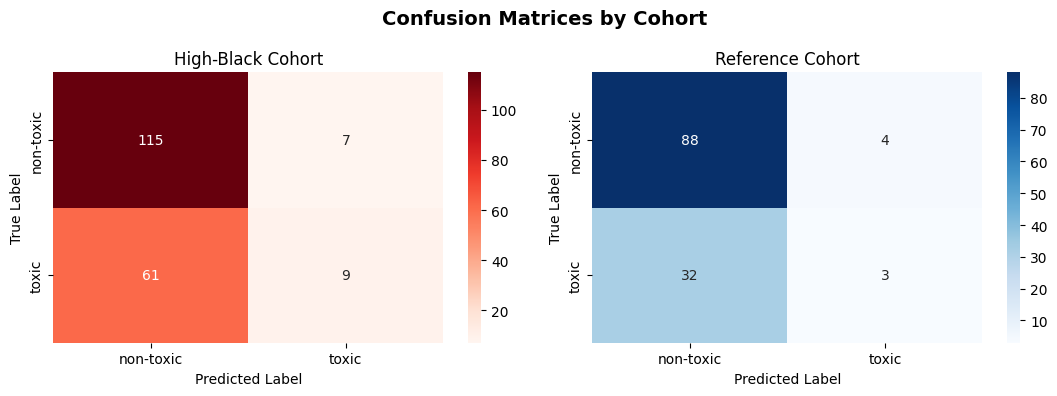

Saved bias_confusion_matrices.png


In [10]:
def plot_cm(df, title, ax):
    cm = confusion_matrix(df['label'], df['pred_label'], labels=[0,1])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Reds' if 'Black' in title else 'Blues',
        xticklabels=['non-toxic','toxic'],
        yticklabels=['non-toxic','toxic'],
        ax=ax,
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cm(df_high_black, 'High-Black Cohort', axes[0])
plot_cm(df_reference,  'Reference Cohort',  axes[1])
plt.suptitle('Confusion Matrices by Cohort', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./bias_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bias_confusion_matrices.png')

## Summary & Interpretation

| Metric | High-Black | Reference | Interpretation |
|--------|-----------|-----------|----------------|
| FPR | higher | lower | Non-toxic comments about Black topics are flagged more |
| FNR | may differ | may differ | Actual toxic content missed at different rates |
| DIR | > 1 | 1.0 (ref) | Disparate impact present |

**Key Finding:** If FPR is substantially higher for the High-Black cohort, the model unfairly flags non-toxic discussions of race as toxic — a well-documented bias in NLP systems trained on internet comments. This motivates the mitigation strategies in Part 4.

**AIF360 Guidance:**
- Statistical Parity Difference near 0 → predictions are equally positive across groups.
- Equal Opportunity Difference near 0 → TPR is similar for both groups.
- Both being non-zero indicates systematic bias requiring mitigation.